# File

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("ML_Ready_Primary.csv") # ETO YUNG GINAMIT KONG CSV YA CHINECK Q NA
X = df.drop('HIV_Status', axis=1)
y = df['HIV_Status']


In [20]:
df.head(10)

,Province,LGU_Classification,Sex,Age_Group,Transmission,Healthcare_Access_Friction,Civil_Status,OFW_Status,Chemsex_Engagement,Alcohol_Sex_Risk,PrEP_Awareness,Transactional_Sex,STI_BBV_CoInfection_Any,HIV_Status
0,Batangas,Municipality,Female,<15,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
1,Batangas,Municipality,Male,15-24,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
2,Batangas,Municipality,Male,15-24,Male to Male Sex,2,Single,No,No,No,Yes,No TS,Yes,Reactive
3,Batangas,Municipality,Male,15-24,Male to Male Sex,2,Single,No,No,No,No,No TS,Yes,Reactive
4,Batangas,Municipality,Male,15-24,Male to Male Sex,2,Single,No,Yes,No,Yes,No TS,No,Reactive
5,Batangas,Municipality,Male,15-24,Male to Male/Female Sex,2,Single,No,No,Yes,Yes,Both,No,Reactive
6,Batangas,Municipality,Male,25-34,Male to Female Sex,2,Common-Law,No,No,No,No,No TS,No,Reactive
7,Batangas,Municipality,Male,25-34,Male to Male Sex,2,Single,No,No,No,Yes,No TS,No,Reactive
8,Batangas,Municipality,Male,25-34,Male to Male Sex,2,Single,No,No,No,No,No TS,No,Reactive
9,Batangas,Municipality,Male,25-34,Male to Male Sex,2,Single,No,No,Yes,Yes,Paid for sex,Yes,Reactive


# Preprocessing

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np

# 1. INITIAL SPLITS
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.25, random_state=42
)

# FIX 2 Kept: Split Validation set in half (Stopping vs Threshold)
X_val_stop, X_val_thresh, y_val_stop, y_val_thresh = train_test_split(
    X_val, y_val, stratify=y_val, test_size=0.5, random_state=42
)

categorical_features = ['Province','LGU_Classification','Sex','Age_Group','Transmission',
                        'Healthcare_Access_Friction','Civil_Status','OFW_Status','Chemsex_Engagement',
                        'Alcohol_Sex_Risk','PrEP_Awareness','Transactional_Sex','STI_BBV_CoInfection_Any']

# 2. ONE-HOT ENCODING
# 'ignore' automatically turns entirely unseen test categories into 0s, solving the Unknowns bug!
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on Train, transform all splits
X_train_processed = encoder.fit_transform(X_train[categorical_features])
X_val_stop_processed = encoder.transform(X_val_stop[categorical_features])
X_val_thresh_processed = encoder.transform(X_val_thresh[categorical_features])
X_test_processed = encoder.transform(X_test[categorical_features])

# 3. TARGET MAPPING
mapping = {'Non-Reactive': 0, 'Reactive': 1}
y_train_processed = y_train.map(mapping).values
y_val_stop_processed = y_val_stop.map(mapping).values
y_val_thresh_processed = y_val_thresh.map(mapping).values
y_test_processed = y_test.map(mapping).values

# Note: No need to convert to dictionaries anymore!

 # MODEL

In [22]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
import tensorflow as tf
import keras_tuner as kt
from sklearn.utils.class_weight import compute_class_weight

# Calculate Initial Output Bias
neg_count = (y_train_processed == 0).sum()
pos_count = (y_train_processed == 1).sum()
initial_bias = np.log([pos_count / neg_count])
output_bias = tf.keras.initializers.Constant(initial_bias)

# Define the standard Dense Model Builder
def build_dense_model(hp):
    # Single Input Layer matching the number of One-Hot columns
    input_layer = Input(shape=(X_train_processed.shape[1],))
    x = input_layer

    # Add Dense Hidden Layers
    hp_neurons = hp.Int('neurons', min_value=64, max_value=256, step=64)
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.3, max_value=0.5, step=0.1)
    hp_dropout_rest = hp.Float('dropout_rest', min_value=0.2, max_value=0.4, step=0.1)

    x = Dense(hp_neurons, activation='swish')(x)
    x = BatchNormalization()(x)
    x = Dropout(hp_dropout_1)(x)

    for i in range(hp.Int('num_layers', 1, 3)):
        x = Dense(hp_neurons // (2**(i+1)), activation='swish')(x)
        x = BatchNormalization()(x)
        x = Dropout(hp_dropout_rest)(x)

    output = Dense(1, activation='sigmoid', bias_initializer=output_bias)(x)
    model = tf.keras.Model(inputs=input_layer, outputs=output)

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
    
    # FIX 3 Kept: Dynamic Balancing Off
    focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
        gamma=2.0, alpha=0.25, label_smoothing=0.1, apply_class_balancing=False
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss=focal_loss,
        metrics=[tf.keras.metrics.AUC(curve='PR', name='auprc')]
    )
    return model

# Calculate Global Class Weights (FIX 3)
classes = np.unique(y_train_processed)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_processed)
global_class_weights = {classes[i]: weights[i] for i in range(len(classes))}
print(f"Using Global Class Weights: {global_class_weights}")

# Initialize Tuner
tuner = kt.RandomSearch( 
    build_dense_model, 
    objective=kt.Objective("val_auprc", direction="max"), 
    max_trials=10, 
    directory='nn_tuning_dir',
    project_name='reactive_dense',
    overwrite=True 
)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(monitor='val_auprc', mode='max', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_auprc', factor=0.2, patience=3, min_lr=1e-6, mode='max', verbose=1)

print("\nCommencing Search with Dense Architecture...")
tuner.search(
    X_train_processed,                                             # Pass raw array now!
    y_train_processed,
    epochs=50,
    batch_size=1024,
    class_weight=global_class_weights,                             
    validation_data=(X_val_stop_processed, y_val_stop_processed),  # Stopping split array
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Extract and Finalize
best_nn_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest Config: Layers: {best_nn_hps.get('num_layers')}, Neurons: {best_nn_hps.get('neurons')}")

best_nn_model = tuner.hypermodel.build(best_nn_hps)

# Final Training
best_nn_model.fit(
    X_train_processed,       
    y_train_processed,
    epochs=100,
    batch_size=1024,
    class_weight=global_class_weights,                             
    validation_data=(X_val_stop_processed, y_val_stop_processed),       
    callbacks=[
        EarlyStopping(monitor='val_auprc', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_auprc', factor=0.1, patience=4, mode='max', verbose=1)
    ],
    verbose=0
)

from sklearn.metrics import precision_recall_curve, classification_report, f1_score, average_precision_score

# 5. Evaluate and Find Optimal Threshold
# --- [IMPROVEMENT 1]: Automated Threshold Finding ---

print("\nFinding Optimal Threshold on the Unseen Validation Threshold Split...")

# CRITICAL FIX: Use X_val_thresh_processed instead of X_val_processed
val_probs_nn = best_nn_model.predict(X_val_thresh_processed, batch_size=1024).ravel()

# CRITICAL FIX: Use y_val_thresh_processed instead of y_val_processed
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh_processed, val_probs_nn)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

print(f"Optimal Operating Threshold: {best_threshold:.4f}")

# Predict on Test Set using the NEW threshold
y_probs_nn = best_nn_model.predict(X_test_processed, batch_size=1024).ravel()
y_pred_nn = (y_probs_nn >= best_threshold).astype(int)

print("\n--- Tuned Neural Network Final Report (Large Scale) ---")
print(classification_report(y_test_processed, y_pred_nn, target_names=['Non Reactive', 'Reactive']))
print(f"Tuned NN F1-Score: {f1_score(y_test_processed, y_pred_nn):.4f}")
print(f"Tuned NN AUPRC: {average_precision_score(y_test_processed, y_probs_nn):.4f}")

Trial 10 Complete [00h 00m 16s]
val_auprc: 0.14580395817756653

Best val_auprc So Far: 0.14965581893920898
Total elapsed time: 00h 04m 09s

Best Config: Layers: 2, Neurons: 192

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 19: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 25: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.

Epoch 29: ReduceLROnPlateau reducing learning rate to 1.0000001111620805e-07.

Epoch 33: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-08.

Epoch 41: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-09.

Epoch 45: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-10.

Epoch 49: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-11.

Epoch 53: ReduceLROnPlateau reducing learning rate to 1.000000082740371e-12.

Finding Optimal Threshold on the Unseen Validation Threshold Split...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Optimal

# Threshold Moving 

In [23]:
import numpy as np
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score,
    precision_recall_curve,
    confusion_matrix,            
    balanced_accuracy_score,     
    brier_score_loss,            # <--- ADDED 
    average_precision_score      # <--- ADDED 
)

# ---------------------------------------------------------
# STEP 1: FIND THE GOLDEN THRESHOLD ON THE *UNSEEN THRESHOLD* SET
# ---------------------------------------------------------

# CRITICAL FIX: Use the specific THRESHOLD split, NOT the entire validation set.
nn_probs_thresh = best_nn_model.predict(X_val_thresh_processed).flatten()

# Get all exact thresholds and their metrics
precisions, recalls, thresholds = precision_recall_curve(y_val_thresh_processed, nn_probs_thresh)

# Calculate F1 scores mathematically (adding 1e-8 prevents division by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Find the "Golden Threshold"
best_idx = np.argmax(f1_scores[:-1]) 
miku_threshold = thresholds[best_idx]

print(f"Golden Threshold (Found on Val Threshold Split): {miku_threshold:.4f}")

# ---------------------------------------------------------
# STEP 2: EVALUATE THIS THRESHOLD ON THE *TEST* SET
# ---------------------------------------------------------

# Now, get probabilities for the untouched test set
nn_probs_test = best_nn_model.predict(X_test_processed).flatten()

# Apply the golden threshold
optimal_preds_test = (nn_probs_test >= miku_threshold).astype(int)

# Standard predictions for comparison
default_preds_test = (nn_probs_test >= 0.5).astype(int)

# --- CALCULATE SPECIFICITY & BALANCED ACCURACY ---
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test_processed, optimal_preds_test).ravel()
specificity_optimal = tn_opt / (tn_opt + fp_opt)

tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test_processed, default_preds_test).ravel()
specificity_default = tn_def / (tn_def + fp_def)

bal_acc_optimal = balanced_accuracy_score(y_test_processed, optimal_preds_test)
bal_acc_default = balanced_accuracy_score(y_test_processed, default_preds_test)

# --- NEW: CALCULATE OVERALL PROBABILITY METRICS ---
auprc_test = average_precision_score(y_test_processed, nn_probs_test)
brier_test = brier_score_loss(y_test_processed, nn_probs_test)

# ---------------------------------------------------------
# PRINT THE FINAL COMPARISON
# ---------------------------------------------------------
print("\n--- FINAL TEST SET PERFORMANCE COMPARISON ---")
print(f"{'Metric':<20} | {'Default (0.5)':<15} | {'Optimized ('+str(round(miku_threshold,2))+')':<15}")
print("-" * 60)
print(f"{'F1-Score':<20} | {f1_score(y_test_processed, default_preds_test):<15.4f} | {f1_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Precision':<20} | {precision_score(y_test_processed, default_preds_test, zero_division=0):<15.4f} | {precision_score(y_test_processed, optimal_preds_test, zero_division=0):<15.4f}")
print(f"{'Recall':<20} | {recall_score(y_test_processed, default_preds_test):<15.4f} | {recall_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Specificity':<20} | {specificity_default:<15.4f} | {specificity_optimal:<15.4f}")
print(f"{'Balanced Accuracy':<20} | {bal_acc_default:<15.4f} | {bal_acc_optimal:<15.4f}")
print("-" * 60)
# --- NEW: PRINT AUPRC & BRIER SCORE ---
print(f"Overall AUPRC (Test Set Power):    {auprc_test:.4f}")
print(f"Overall Brier Score (Calibration): {brier_test:.4f}")

1020/1020 ━━━━━━━━━━━━━━━━━━━━ 0s 272us/step
Golden Threshold (Found on Val Threshold Split): 0.5048
2040/2040 ━━━━━━━━━━━━━━━━━━━━ 1s 262us/step

--- FINAL TEST SET PERFORMANCE COMPARISON ---
Metric               | Default (0.5)   | Optimized (0.5)
------------------------------------------------------------
F1-Score             | 0.1995          | 0.2000         
Precision            | 0.1270          | 0.1276         
Recall               | 0.4653          | 0.4619         
Specificity          | 0.7361          | 0.7395         
Balanced Accuracy    | 0.6007          | 0.6007         
------------------------------------------------------------
Overall AUPRC (Test Set Power):    0.1349
Overall Brier Score (Calibration): 0.2318


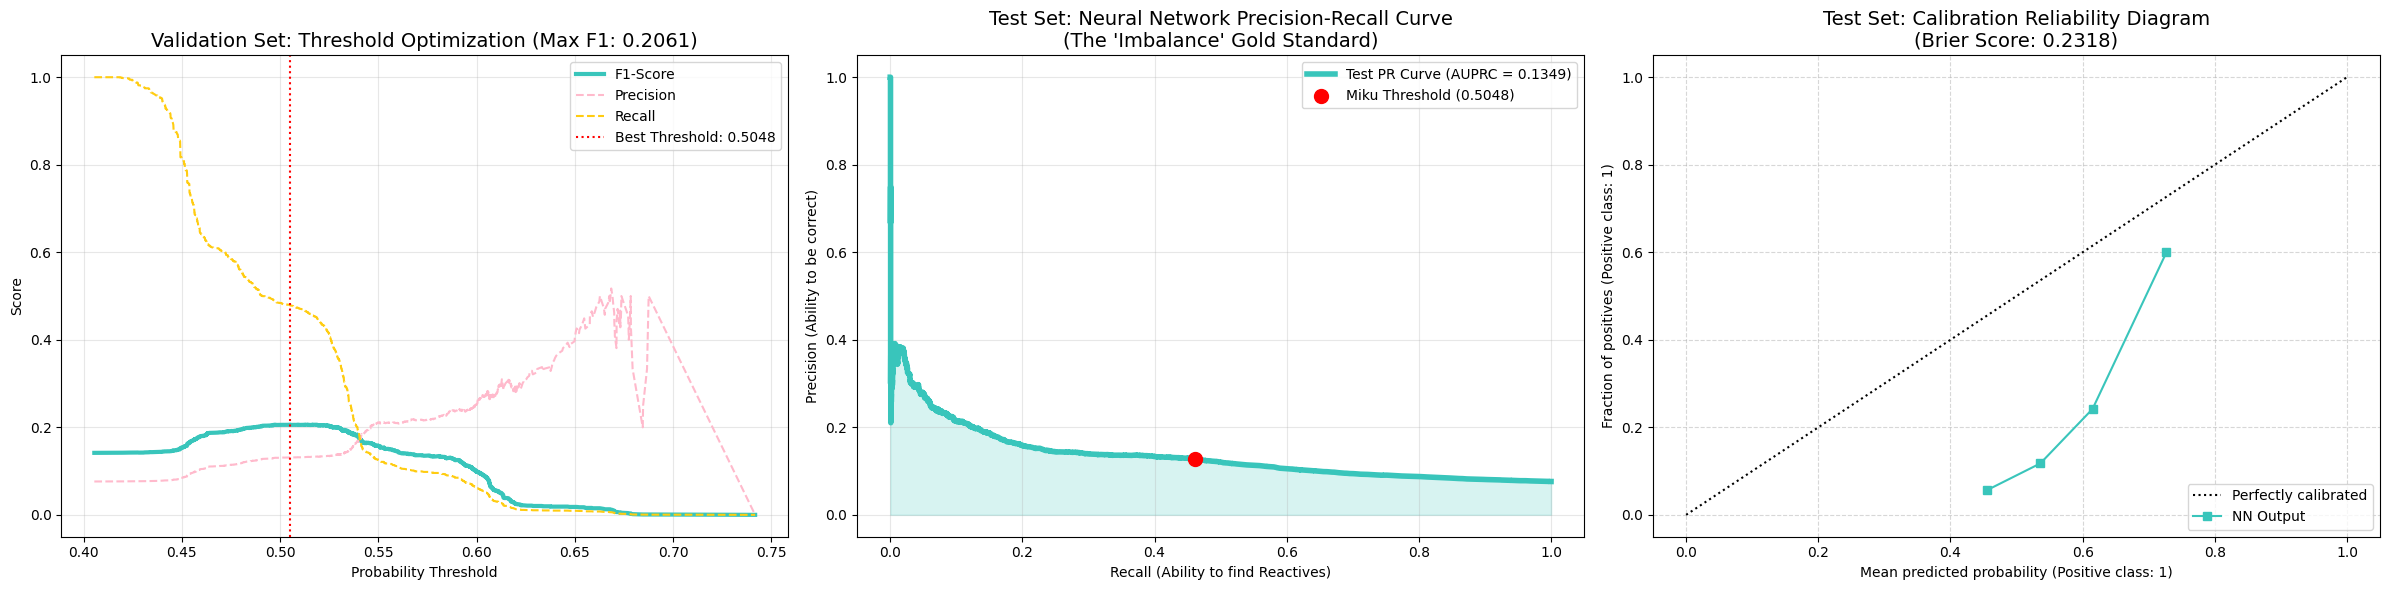

--- NN Results (Test Set) ---
Original F1 (50%): 0.1995
Optimized F1 (50%): 0.2000


In [24]:
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score, brier_score_loss
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get the max F1 score from the validation set for your plot title
best_f1_val = f1_scores[best_idx]

# Calculate PR Curve data using the UNTOUCHED Test Set
precision_nn, recall_nn, pr_thresholds_nn = precision_recall_curve(y_test_processed, nn_probs_test)
auprc_nn = average_precision_score(y_test_processed, nn_probs_test)

# --- NEW: Calculate Brier Score right here so the plot never fails! ---
brier_test = brier_score_loss(y_test_processed, nn_probs_test)

# Create a 1x3 subplot figure (Expanded to fit Calibration)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

# =========================================================
# PLOT 1: THRESHOLD VS METRICS (THE VALIDATION SET STORY)
# =========================================================
ax1.plot(thresholds, f1_scores[:-1], label='F1-Score', color='#39C5BB', linewidth=3) # Miku Teal
ax1.plot(thresholds, precisions[:-1], label='Precision', color='#FFBACC', linestyle='--') # Luka Pink
ax1.plot(thresholds, recalls[:-1], label='Recall', color='#FFCC11', linestyle='--')    # Rin Yellow

ax1.axvline(miku_threshold, color='red', linestyle=':', label=f'Best Threshold: {miku_threshold:.4f}')

ax1.set_title(f"Validation Set: Threshold Optimization (Max F1: {best_f1_val:.4f})", fontsize=14)
ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(alpha=0.3)

# =========================================================
# PLOT 2: PRECISION-RECALL CURVE (THE TEST SET PROOF)
# =========================================================
ax2.plot(recall_nn, precision_nn, color='#39C5BB', linewidth=4, label=f'Test PR Curve (AUPRC = {auprc_nn:.4f})')
ax2.fill_between(recall_nn, 0, precision_nn, color='#39C5BB', alpha=0.2)

# Mark where "miku_threshold" lands on the TEST set's curve
idx_nn = np.argmin(np.abs(pr_thresholds_nn - miku_threshold))
ax2.scatter(recall_nn[idx_nn], precision_nn[idx_nn], color='red', s=100, zorder=5, label=f'Miku Threshold ({miku_threshold:.4f})')

ax2.set_title("Test Set: Neural Network Precision-Recall Curve\n(The 'Imbalance' Gold Standard)", fontsize=14)
ax2.set_xlabel("Recall (Ability to find Reactives)")
ax2.set_ylabel("Precision (Ability to be correct)")
ax2.legend()
ax2.grid(alpha=0.3)

# =========================================================
# PLOT 3: CALIBRATION RELIABILITY DIAGRAM
# =========================================================
CalibrationDisplay.from_predictions(
    y_test_processed, 
    nn_probs_test, 
    n_bins=10, 
    name="NN Output",
    ax=ax3,
    color='#39C5BB'
)

ax3.set_title(f"Test Set: Calibration Reliability Diagram\n(Brier Score: {brier_test:.4f})", fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# =========================================================
# PRINT RESULTS (THE TEST SET TRUTH)
# =========================================================
print(f"--- NN Results (Test Set) ---")
print(f"Original F1 (50%): {f1_score(y_test_processed, default_preds_test):.4f}")
print(f"Optimized F1 ({miku_threshold*100:.0f}%): {f1_score(y_test_processed, optimal_preds_test):.4f}")

# SHAP

In [25]:
import shap
import numpy as np
import pandas as pd

# 1. Background Data Selection (NumPy safe)
# Since X_train_processed is a NumPy array, we use SHAP's native sampler
background_data = shap.sample(X_train_processed, 100)

# Initialize the Gradient Explainer
explainer_nn = shap.GradientExplainer(best_nn_model, background_data)

# Calculate SHAP values for the test set
# (You might want to wrap this in shap.sample(X_test_processed, 500) if it takes too long!)
shap_vals_nn = explainer_nn.shap_values(X_test_processed)

# 2. Handle Keras Output Shapes
if isinstance(shap_vals_nn, list):
    shap_raw_nn = shap_vals_nn[0]
else:
    shap_raw_nn = shap_vals_nn

# Reshape to a clean 2D array (sometimes Keras returns a 3D tensor like (N, Features, 1))
if len(shap_raw_nn.shape) == 3:
    shap_raw_nn = shap_raw_nn.reshape(shap_raw_nn.shape[0], shap_raw_nn.shape[1])

# 3. Extract the exact feature names from your One-Hot Encoder!
# This automatically creates names like "Sex_Male", "Age_Group_25-34", etc.
ohe_feature_names = encoder.get_feature_names_out(categorical_features)

# Put them in a DataFrame for easy grouping
shap_df_nn = pd.DataFrame(shap_raw_nn, columns=ohe_feature_names)
grouped_shap_df_nn = shap_df_nn.copy()

# 4. Stitch the dummy columns back together!
for original_col in categorical_features:
    # Find all one-hot encoded columns that belong to this original feature
    dummy_cols = [col for col in ohe_feature_names if col.startswith(f"{original_col}_")]

    if len(dummy_cols) > 0:
        # Sum the SHAP values of the dummy parts to get the total importance for the category
        grouped_shap_df_nn[original_col] = shap_df_nn[dummy_cols].sum(axis=1)
        # Drop the diluted dummy columns
        grouped_shap_df_nn.drop(columns=dummy_cols, inplace=True)

print("SHAP dummy columns successfully stitched back together!")


/opt/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(65264, 42))']
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(50, 42))']
  warnings.warn(msg)


SHAP dummy columns successfully stitched back together!


/var/folders/n7/5_69qws5077gwwg97fhrzrm40000gn/T/ipykernel_12225/2686581109.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(grouped_shap_df_nn.values, color="#39C5BB", features=grouped_shap_df_nn.columns, plot_type="bar")


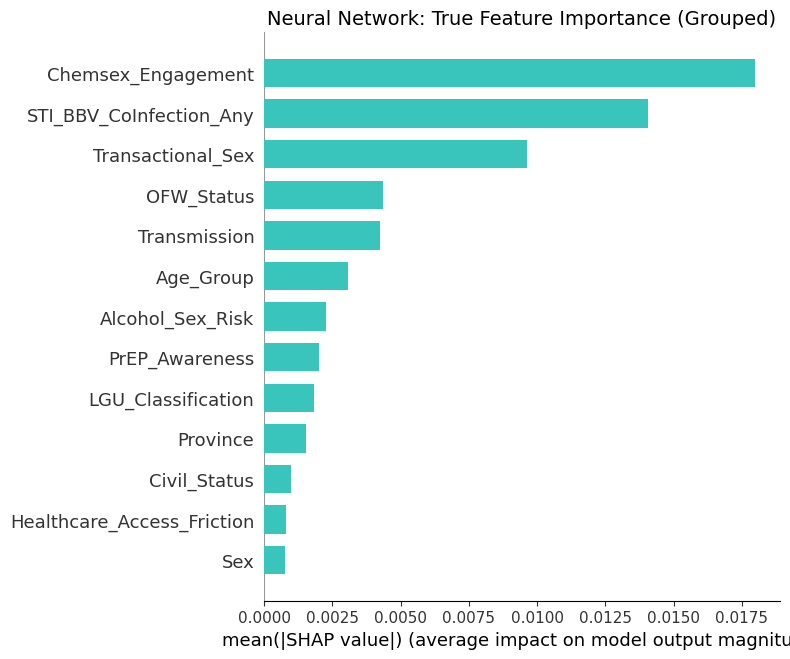

<Figure size 640x480 with 0 Axes>

In [26]:
# 5. Plot the Global Feature Importance (Miku Teal!)
plt.figure(figsize=(12, 8))
plt.title(f"Neural Network: True Feature Importance (Grouped)", fontsize=14)
shap.summary_plot(grouped_shap_df_nn.values, color="#39C5BB", features=grouped_shap_df_nn.columns, plot_type="bar")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE IMPORTANCE

/var/folders/n7/5_69qws5077gwwg97fhrzrm40000gn/T/ipykernel_12225/3313898120.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


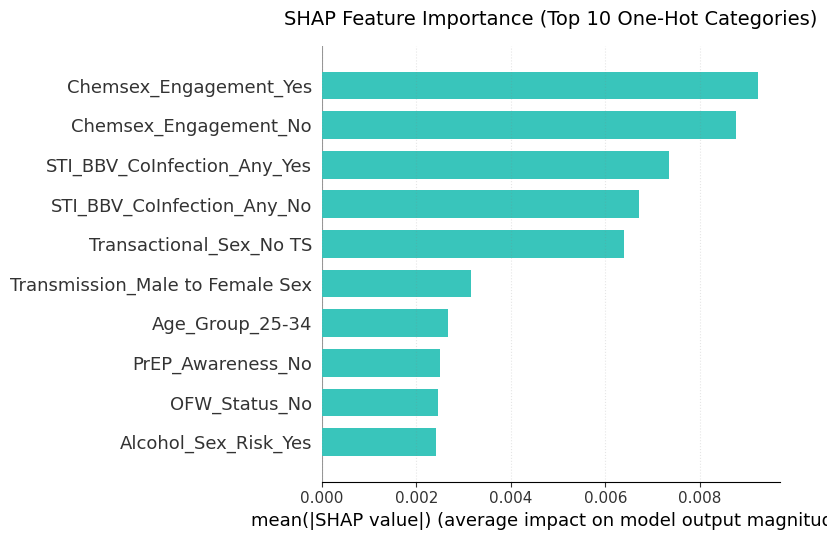

In [30]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_raw_nn,                         # <-- The raw 2D SHAP array
    features=X_test_processed,           # <-- The NumPy test array
    feature_names=ohe_feature_names,     # <-- The dynamic names (e.g., 'Sex_Male')
    plot_type="bar",
    color = "#39C5BB",
    max_display=10,                      # Shows the top 10 most impactful dummy categories
    show=False                           # Prevents duplicate plotting
)
# Optional: Add a title so it matches your other graphics!
plt.title("SHAP Feature Importance (Top 10 One-Hot Categories)", fontsize=14, pad=15)
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

## Beeswarm

/var/folders/n7/5_69qws5077gwwg97fhrzrm40000gn/T/ipykernel_12225/3539473444.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


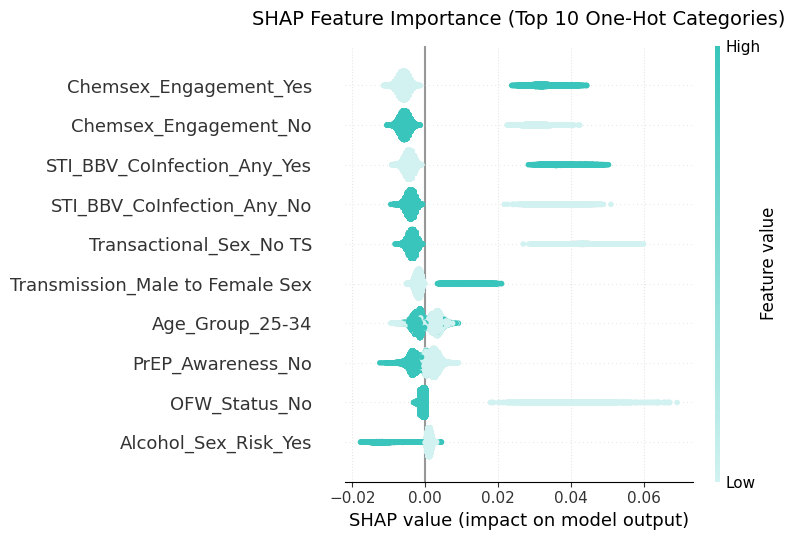

In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shap

plt.figure(figsize=(10, 6))

# Custom Hatsune Miku Gradient (Low = Pale Blue, High = Miku Teal)
miku_cmap = mcolors.LinearSegmentedColormap.from_list("miku_gradient", ["#D1F2F0", "#39C5BB"])

# Generate the Beeswarm Plot using the exact variables from the previous block
shap.summary_plot(
    shap_raw_nn,                         # <-- The raw 2D SHAP array
    features=X_test_processed,           # <-- The NumPy test array
    feature_names=ohe_feature_names,     # <-- The dynamic names (e.g., 'Sex_Male')
    plot_type="dot",
    cmap=miku_cmap,
    max_display=10,                      # Shows the top 10 most impactful dummy categories
    show=False                           # Prevents duplicate plotting
)

# Optional: Add a title so it matches your other graphics!
plt.title("SHAP Feature Importance (Top 10 One-Hot Categories)", fontsize=14, pad=15)
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

# SAVING THE MODEL (RUN MO TO YA IF YOU THINK MAGANDA RESULT PARA MASAVE)

In [32]:
import joblib
import json

# A. Save the Neural Network Model (Keras format)
best_nn_model.save("nn_hiv_model.keras")

# B. Save the OneHotEncoder 
# (You MUST save this or you won't be able to process new patients!)
joblib.dump(encoder, "nn_onehot_encoder.joblib")

# C. Save the Threshold and other Metadata
metadata = {
    "miku_threshold": float(miku_threshold),
    "categorical_features": categorical_features,
    "target_mapping": {"Non-Reactive": 0, "Reactive": 1}
}

with open("nn_model_metadata.json", "w") as f:
    json.dump(metadata, f)

print("Model, Encoder, and Threshold saved successfully!")

Model, Encoder, and Threshold saved successfully!


In [18]:
import tensorflow as tf
import joblib
import json
import numpy as np
import pandas as pd

# 1. LOAD EVERYTHING
loaded_model = tf.keras.models.load_model("nn_hiv_model.keras")
loaded_encoder = joblib.load("nn_onehot_encoder.joblib")

with open("nn_model_metadata.json", "r") as f:
    loaded_meta = json.load(f)
    operating_threshold = loaded_meta["miku_threshold"]

# 2. PREDICT ON NEW DATA (Example row)
new_data = pd.DataFrame([{
    'Sex': 'Male',
    'Age_Group': '25-34',
    'Transmission': 'MSM',
    'Healthcare_Access_Friction': 'No',
    'Civil_Status': 'Single',
    'OFW_Status': 'No',
    'Chemsex_Engagement': 'No',
    'Alcohol_Sex_Risk': 'Yes',
    'PrEP_Awareness': 'Yes',
    'Transactional_Sex': 'No',
    'STI_BBV_CoInfection_Any': 'No'
}])

# Translate strings to One-Hot array
new_data_processed = loaded_encoder.transform(new_data)

# Get raw probability
prob = loaded_model.predict(new_data_processed, verbose=0).ravel()[0]

# Apply Golden Threshold
prediction = "Reactive" if prob >= operating_threshold else "Non-Reactive"

print(f"Probability: {prob:.4f}")
print(f"Decision: {prediction} (Threshold: {operating_threshold:.4f})")

Probability: 0.5470
Decision: Reactive (Threshold: 0.5199)
